In [141]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt

os.chdir("C:\\Users\\ASUS\\OneDrive - HKUST Connect\\1_Projects\\ASTRI\\Project folder\\Hole detection")
print(os.getcwd())

def plot_simulation_data(OUTPUT_SIM_DATA):
# Load the dictionary
    with open(OUTPUT_SIM_DATA, 'rb') as f:
        simulation_data = pickle.load(f)

    # Now you can use it!
    print(simulation_data.keys())
    print(f"# inner poirnts: {len(simulation_data['inner_points'])}")
    print(f"avg_dup_rate: {np.mean(simulation_data['dup_rate_history'])}")

    dup_rate_history = simulation_data['dup_rate_history']
    escape_history = simulation_data['escape_history']
    add_count_history = simulation_data['add_count_history']
    add_count_integral = np.cumsum(add_count_history)
    window_size = 10
    add_count_history = np.convolve(add_count_history, np.ones(window_size)/window_size, mode='valid')
    # plot the history of duplication rate
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 2, 1)
    plt.plot(range(len(dup_rate_history)), dup_rate_history)
    plt.xlabel("step")
    plt.ylabel("duplication rate")
    plt.ylim(0, 1)
    plt.subplot(2, 2, 2)
    plt.plot(range(len(escape_history)), escape_history)
    plt.xlabel("step")
    plt.ylabel("escape_history")
    plt.subplot(2, 2, 3)
    plt.plot(range(len(add_count_history)), add_count_history)
    plt.xlabel("step")
    plt.ylabel("add count per ball")
    plt.subplot(2, 2, 4)
    plt.plot(range(len(add_count_integral)), add_count_integral)
    plt.xlabel("step")
    plt.ylabel("add count cummulative")
    plt.show()

C:\Users\ASUS\OneDrive - HKUST Connect\1_Projects\ASTRI\Project folder\Hole detection


### Effect of diffusion enable

Load dict from simulation main.py

In [142]:
# Path to your saved .pkl file
INPUT_PLY_FILE = "./ply_files/test ply inputs/test point cloud shell_1.ply"
OUTPUT_DIR = "./ply_files/output/"
OUTPUT_PLY_FILE = "./ply_files/output/output1.ply"
OUTPUT_SIM_DATA_1 = "./ply_files/sim_data/sim_data_no_diffusion.ply"
OUTPUT_SIM_DATA_2 = "./ply_files/sim_data/sim_data1_diff1.ply"

# Load the dictionary
with open(OUTPUT_SIM_DATA_1, 'rb') as f:
    simulation_data_no_diffusion = pickle.load(f)

with open(OUTPUT_SIM_DATA_2, 'rb') as f:
    simulation_data_with_diffusion = pickle.load(f)

# Now you can use it!
print(simulation_data_with_diffusion)
print(simulation_data_with_diffusion.keys())
print(f"# inner poirnts: {len(simulation_data_with_diffusion['inner_points'])}")

{'inner_points': [array([-0.70951369, 39.67543293, 48.10772564]), array([-3.01421094, 29.66666412, 50.22250366]), array([-4.79247284, 57.        , 47.52687073]), array([-4.34315872, 57.        , 52.10302734]), array([-0.82949448, 29.66666603, 47.31299591]), array([-0.9384079 , 57.        , 48.18696976]), array([-21.57255363,  39.58617401,  97.        ]), array([-57.61336136,  45.34707642,   3.        ]), array([-87.        ,  50.55278015,  83.02318573]), array([-76.80976105,  46.61477661,  97.00000763]), array([-52.88676834,  38.13896942,   3.        ]), array([-42.03868103,  29.66666603,  48.03090286]), array([-50.91259003,  57.        ,  67.86212158]), array([-52.35192108,  41.53607178,  97.        ]), array([-55.24150085,  17.40355682,   3.        ]), array([-55.95965576,  -8.69419003,  97.        ]), array([-71.21792603, -33.04122543,   1.50428963]), array([-75.9262619 , -57.15174866,  78.34492493]), array([-75.80344391, -34.93586731,  97.10380554]), array([-11.53983402,  29.666664

Plot dup rate

Without diffusion

In [143]:
print(f"avg_dup_rate: {np.mean(simulation_data_no_diffusion['dup_rate_history'])}")

avg_dup_rate: 0.5999683801819814


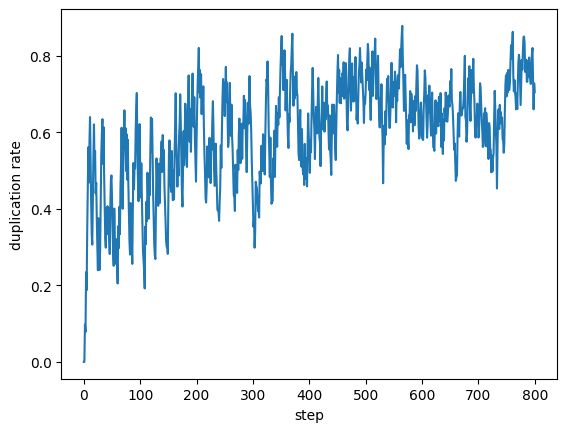

In [144]:
dup_rate_history = simulation_data_no_diffusion['dup_rate_history']
# plot the history of duplication rate
plt.plot(range(len(dup_rate_history)), dup_rate_history)
plt.xlabel("step")
plt.ylabel("duplication rate")
plt.show()

With diffusion

In [145]:
print(f"avg_dup_rate: {np.mean(simulation_data_with_diffusion['dup_rate_history'])}")

avg_dup_rate: 0.6192787643619092


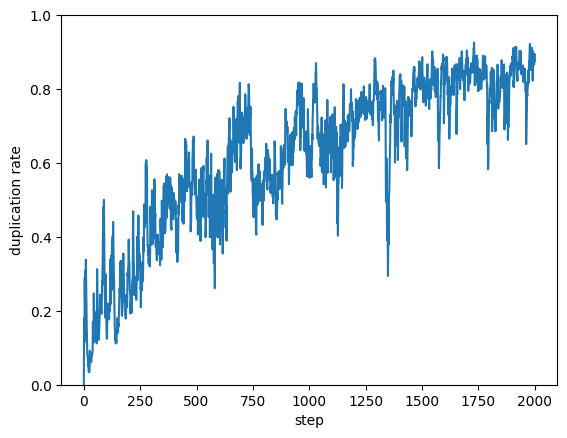

In [146]:
dup_rate_history = simulation_data_with_diffusion['dup_rate_history']
# plot the history of duplication rate
plt.plot(range(len(dup_rate_history)), dup_rate_history)
plt.xlabel("step")
plt.ylabel("duplication rate")
plt.ylim(0, 1)
plt.show()

### Test: Ball size ratio: 0.01
* before it is 0.015

{'inner_points': [array([-0.70951369, 39.67543293, 48.10772564]), array([ 0.81202888, 29.66666603, 50.40755081]), array([-0.9384079 , 57.        , 48.18696976]), array([-4.97941685, 29.66666794, 51.06103134]), array([-5.00834656, 57.        , 53.59645081]), array([-6.48561478, 29.66666603, 50.60349655]), array([-8.04362106, 57.        , 50.3155632 ]), array([-10.98963451,  29.66666603,  42.75120163]), array([-12.30501556,  57.        ,  37.19665146]), array([-14.43302155,  29.66666603,  30.78177834]), array([-18.80986595,  57.        ,  24.79872704]), array([-21.01499939,  29.66666603,  20.27704048]), array([-22.61506653,  57.        ,  17.20889664]), array([-26.4694519 ,  29.66666603,   6.38651085]), array([-29.16403961,  57.        ,  13.57716656]), array([-31.77928543,  29.66666603,  17.48004913]), array([-29.89229202,  57.00000381,  18.71033287]), array([-27.7007122 ,  29.66666603,  24.84812546]), array([-27.66606331,  57.        ,  25.92649651]), array([-29.823349  ,  29.66666412,

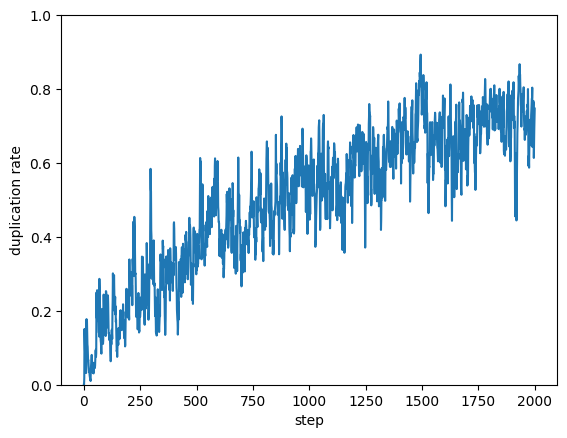

In [147]:
# Path to your saved .pkl file
SIMULATION_NAME = "test_ball_0.01"
INPUT_PLY_FILE = "./ply_files/test ply inputs/test point cloud shell_1.ply"
OUTPUT_DIR = "./ply_files/output/"
OUTPUT_PLY_FILE = f"./ply_files/sim_data/output_{SIMULATION_NAME}.ply"
OUTPUT_SIM_DATA = f"./ply_files/sim_data/sim_data_{SIMULATION_NAME}.ply"

# Load the dictionary
with open(OUTPUT_SIM_DATA, 'rb') as f:
    simulation_data = pickle.load(f)

# Now you can use it!
print(simulation_data)
print(simulation_data.keys())
print(f"# inner poirnts: {len(simulation_data['inner_points'])}")

print(f"avg_dup_rate: {np.mean(simulation_data['dup_rate_history'])}")

dup_rate_history = simulation_data['dup_rate_history']
# plot the history of duplication rate
plt.plot(range(len(dup_rate_history)), dup_rate_history)
plt.xlabel("step")
plt.ylabel("duplication rate")
plt.ylim(0, 1)
plt.show()

Test perturbation

{'inner_points': [[0, 0, 0], array([29.44902039, 31.75468063, -7.07592869]), array([ 60.38021088, -33.11064911,   6.54239178]), array([ 61.54623032, -30.35722733,  37.25367737]), array([ 91.46930695, -23.49002266,  16.98740005]), array([119.13119507,  24.00035477,  30.49859428]), array([ 78.11691284, -22.0897522 ,  65.76519012]), array([107.2689209 , -33.76942062,  65.6504364 ]), array([87.93624878, -1.9963485 , 67.65313721]), array([135.99139404,  11.67138672,  47.53049469]), array([82.91818237, -6.41543388, 60.20071411]), array([ 93.20774841, -41.66294479,  50.26139069]), array([ 73.65655518, -30.54206085,  50.66064072]), array([84.0962677 , 31.04294968,  8.6178093 ]), array([ 74.57262421, -21.30659103,   0.74114352]), array([51.46102142,  7.29237795, 22.4350853 ]), array([39.92583466, 32.19600677,  5.27047873]), array([ 35.55015564, -33.67417908,   0.81545651]), array([ 42.2953949 , -26.53892326,  29.6728344 ]), array([99.36547852,  7.19709396, -9.63294601]), array([ 72.81019592, -2

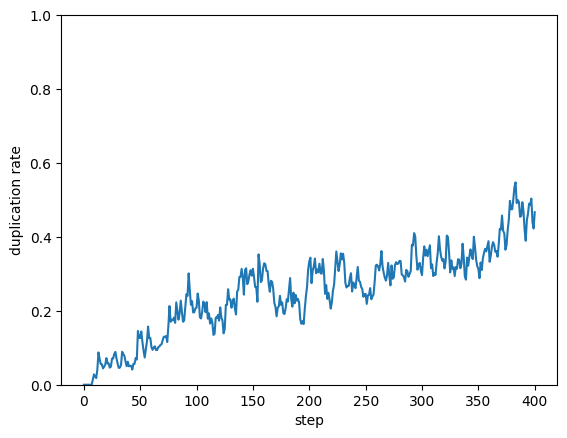

In [148]:
# Path to your saved .pkl file
SIMULATION_NAME = "test_perturbation"
INPUT_PLY_FILE = "./ply_files/test ply inputs/test point cloud shell_1.ply"
OUTPUT_DIR = "./ply_files/output/"
OUTPUT_PLY_FILE = f"./ply_files/sim_data/output_{SIMULATION_NAME}.ply"
OUTPUT_SIM_DATA = f"./ply_files/sim_data/sim_data_{SIMULATION_NAME}.ply"

# Load the dictionary
with open(OUTPUT_SIM_DATA, 'rb') as f:
    simulation_data = pickle.load(f)

# Now you can use it!
print(simulation_data)
print(simulation_data.keys())
print(f"# inner poirnts: {len(simulation_data['inner_points'])}")

print(f"avg_dup_rate: {np.mean(simulation_data['dup_rate_history'])}")

dup_rate_history = simulation_data['dup_rate_history']
# plot the history of duplication rate
plt.plot(range(len(dup_rate_history)), dup_rate_history)
plt.xlabel("step")
plt.ylabel("duplication rate")
plt.ylim(0, 1)
plt.show()

## Hour glass closed

dict_keys(['inner_points', 'dup_count_history', 'escaped_count', 'time_elapsed', 'config', 'add_count_history', 'dup_rate_history', 'escape_history', 'metrics'])
# inner poirnts: 14835
avg_dup_rate: 0.8497755579052131


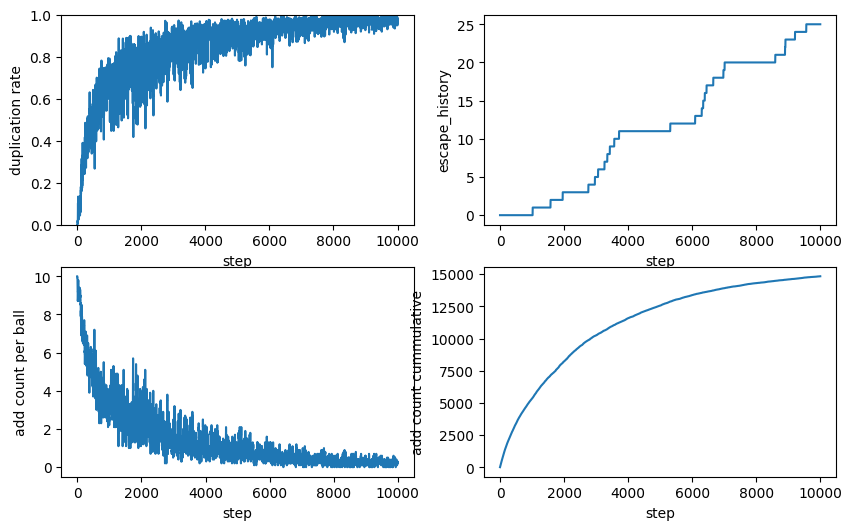

In [167]:
# Path to your saved .pkl file
SIMULATION_NAME = "hourglass_closed"
OUTPUT_DIR = "./ply_files/output/"
OUTPUT_PLY_FILE = f"./ply_files/output/output_{SIMULATION_NAME}.ply"
OUTPUT_SIM_DATA = f"./ply_files/sim_data/sim_data_{SIMULATION_NAME}.ply"
plot_simulation_data(OUTPUT_SIM_DATA)

## Hour glass opened

dict_keys(['inner_points', 'dup_count_history', 'escaped_count', 'time_elapsed', 'config', 'add_count_history', 'dup_rate_history', 'escape_history', 'metrics'])
# inner poirnts: 2732
avg_dup_rate: 0.19985494916310306


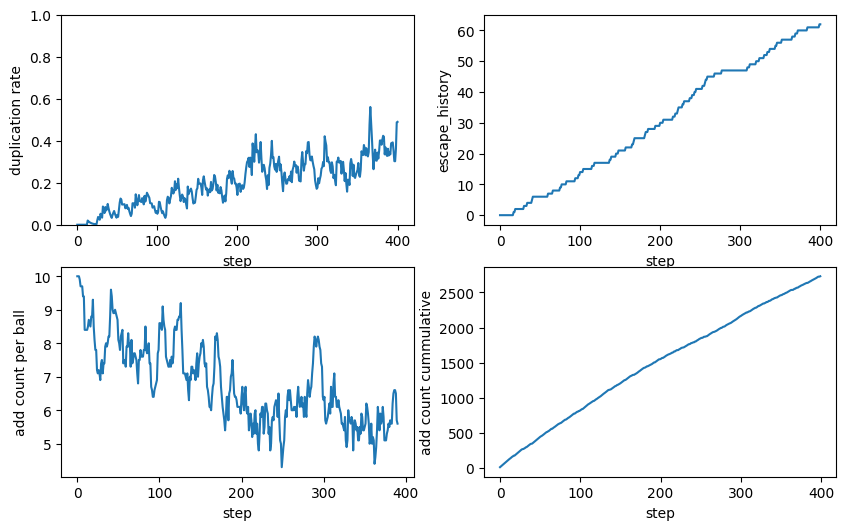

In [150]:
# Path to your saved .pkl file
SIMULATION_NAME = "hourglass_opened"
OUTPUT_DIR = "./ply_files/output/"
OUTPUT_PLY_FILE = f"./ply_files/output/output_{SIMULATION_NAME}.ply"
OUTPUT_SIM_DATA = f"./ply_files/sim_data/sim_data_{SIMULATION_NAME}.ply"
plot_simulation_data(OUTPUT_SIM_DATA)

## Snail

dict_keys(['inner_points', 'dup_count_history', 'escaped_count', 'time_elapsed', 'config', 'add_count_history', 'dup_rate_history', 'escape_history', 'metrics'])
# inner poirnts: 17649
avg_dup_rate: 0.8076136591258506


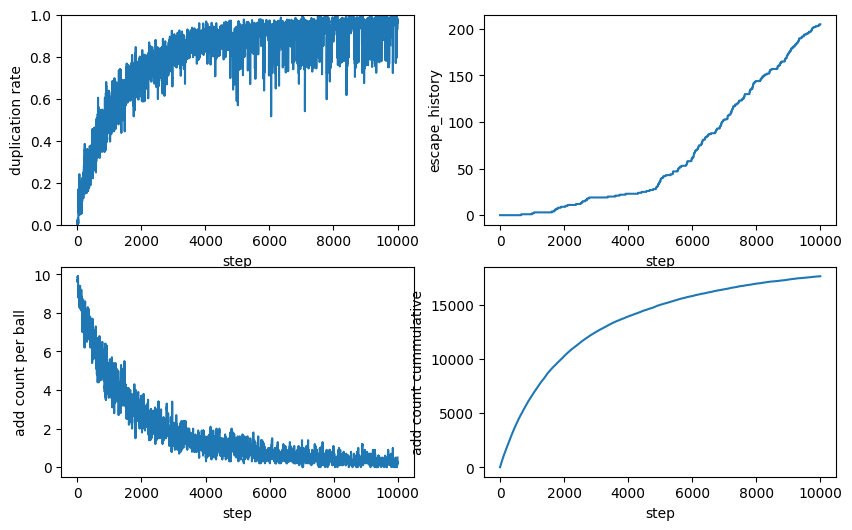

In [174]:
# Path to your saved .pkl file
SIMULATION_NAME = "snail"
OUTPUT_DIR = "./ply_files/output/"
OUTPUT_PLY_FILE = f"./ply_files/output/output_{SIMULATION_NAME}.ply"
OUTPUT_SIM_DATA = f"./ply_files/sim_data/sim_data_{SIMULATION_NAME}.ply"
plot_simulation_data(OUTPUT_SIM_DATA)

## Sphere

dict_keys(['inner_points', 'dup_count_history', 'escaped_count', 'time_elapsed', 'config', 'add_count_history', 'dup_rate_history', 'escape_history', 'metrics'])
# inner poirnts: 1859
avg_dup_rate: 0.13588033510748507


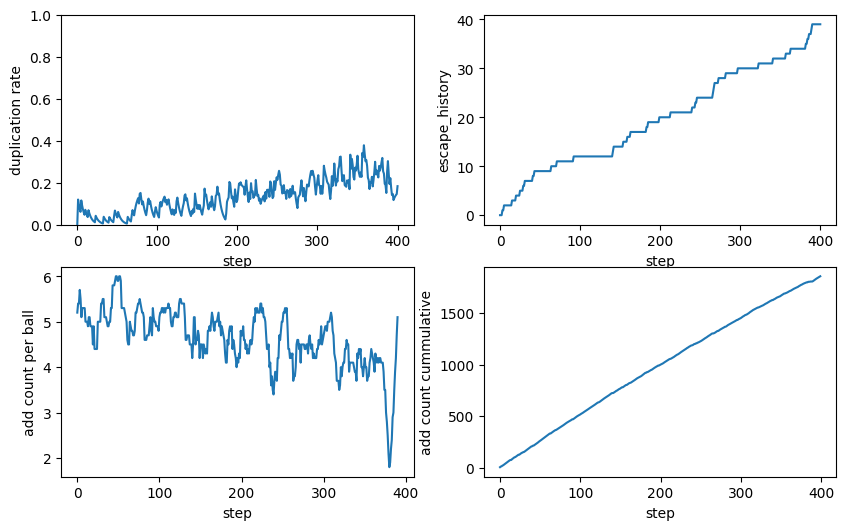

In [152]:
# Path to your saved .pkl file
SIMULATION_NAME = "sphere"
OUTPUT_DIR = "./ply_files/output/"
OUTPUT_PLY_FILE = f"./ply_files/output/output_{SIMULATION_NAME}.ply"
OUTPUT_SIM_DATA = f"./ply_files/sim_data/sim_data_{SIMULATION_NAME}.ply"
plot_simulation_data(OUTPUT_SIM_DATA)

### Stomach_1

dict_keys(['inner_points', 'dup_count_history', 'escaped_count', 'time_elapsed', 'config', 'add_count_history', 'dup_rate_history', 'escape_history', 'metrics'])
# inner poirnts: 16082
avg_dup_rate: 0.6764430063419111


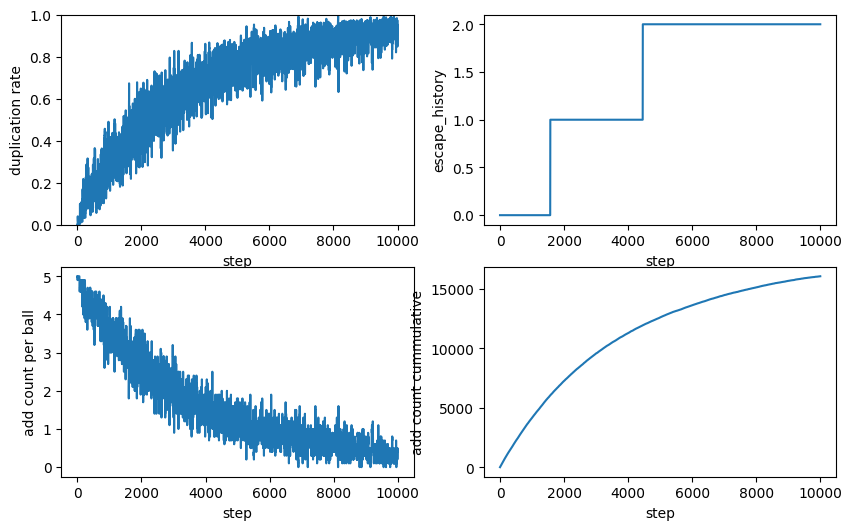

In [168]:
# Path to your saved .pkl file
SIMULATION_NAME = "stomach_1"
OUTPUT_DIR = "./ply_files/output/"
OUTPUT_PLY_FILE = f"./ply_files/output/output_{SIMULATION_NAME}.ply"
OUTPUT_SIM_DATA = f"./ply_files/sim_data/sim_data_{SIMULATION_NAME}.ply"
plot_simulation_data(OUTPUT_SIM_DATA)

### Stomach 2

dict_keys(['inner_points', 'dup_count_history', 'escaped_count', 'time_elapsed', 'config', 'add_count_history', 'dup_rate_history', 'escape_history', 'metrics'])
# inner poirnts: 27575
avg_dup_rate: 0.7218511925689042


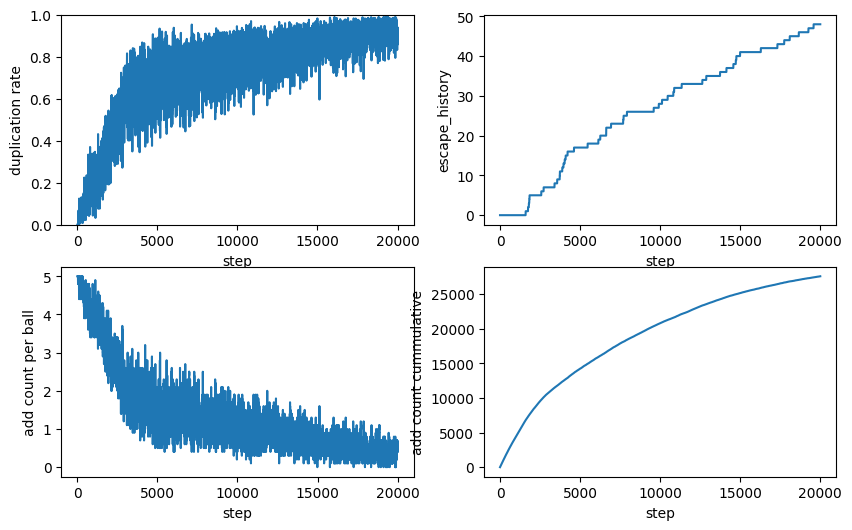

In [169]:
# Path to your saved .pkl file
SIMULATION_NAME = "stomach_2"
OUTPUT_DIR = "./ply_files/output/"
OUTPUT_PLY_FILE = f"./ply_files/output/output_{SIMULATION_NAME}.ply"
OUTPUT_SIM_DATA = f"./ply_files/sim_data/sim_data_{SIMULATION_NAME}.ply"
plot_simulation_data(OUTPUT_SIM_DATA)

### Stomach 3

dict_keys(['inner_points', 'dup_count_history', 'escaped_count', 'time_elapsed', 'config', 'add_count_history', 'dup_rate_history', 'escape_history', 'metrics'])
# inner poirnts: 14339
avg_dup_rate: 0.6506542922137746


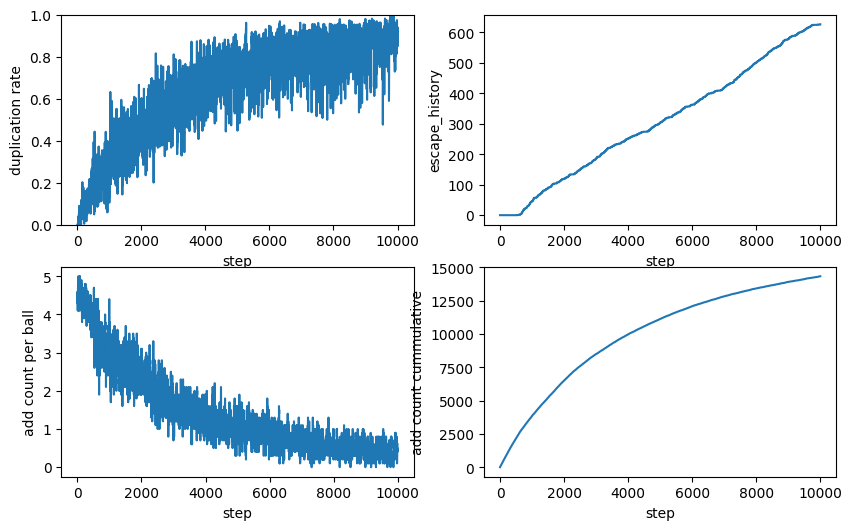

In [163]:
# Path to your saved .pkl file
SIMULATION_NAME = "stomach_3"
OUTPUT_DIR = "./ply_files/output/"
OUTPUT_PLY_FILE = f"./ply_files/output/output_{SIMULATION_NAME}.ply"
OUTPUT_SIM_DATA = f"./ply_files/sim_data/sim_data_{SIMULATION_NAME}.ply"
plot_simulation_data(OUTPUT_SIM_DATA)

In [156]:
## check if file exists
import os

INPUT_PLY_FILE = "./scripts/"

# Check if path exists (file or directory)
if os.path.exists(INPUT_PLY_FILE):
    print(f"{INPUT_PLY_FILE} exists")
else:
    print(f"{INPUT_PLY_FILE} does not exist")

./scripts/ exists


In [157]:
import numpy as np
import open3d as o3d
import math
import random
import time
from tqdm import tqdm
import os
import multiprocessing as mp
import queue
import copy
from pynput import keyboard
import json
import pickle as pkl
os.chdir("C:\\Users\\ASUS\\OneDrive - HKUST Connect\\1_Projects\\ASTRI\\Project folder\\Hole detection\\hole_detection")
from SimulationEngine import *
os.chdir("C:\\Users\\ASUS\\OneDrive - HKUST Connect\\1_Projects\\ASTRI\\Project folder\\Hole detection")
INPUT_PLY_FILE = "./scripts/centered_cloud.ply"
point_cloud = PointCloud(INPUT_PLY_FILE)
# plot point cloud
o3d.visualization.draw_geometries([point_cloud.pcd])

In [158]:
## check if file exists
import os

INPUT_PLY_FILE = "./scripts/"

# Check if path exists (file or directory)
if os.path.exists(INPUT_PLY_FILE):
    print(f"{INPUT_PLY_FILE} exists")
else:
    print(f"{INPUT_PLY_FILE} does not exist")

./scripts/ exists


In [159]:
import numpy as np
import open3d as o3d
import math
import random
import time
from tqdm import tqdm
import os
import multiprocessing as mp
import queue
import copy
from pynput import keyboard
import json
import pickle as pkl
os.chdir("C:\\Users\\ASUS\\OneDrive - HKUST Connect\\1_Projects\\ASTRI\\Project folder\\Hole detection\\hole_detection")
from SimulationEngine import *
os.chdir("C:\\Users\\ASUS\\OneDrive - HKUST Connect\\1_Projects\\ASTRI\\Project folder\\Hole detection")
INPUT_PLY_FILE = "./scripts/centered_cloud.ply"
point_cloud = PointCloud(INPUT_PLY_FILE)
# plot point cloud
o3d.visualization.draw_geometries([point_cloud.pcd])